# FRAUD TRANSACTION DETECTION

## OBJECTIVE

Build a system that can classify whether a transaction is fraudulent or legitimate using machine learning techniques.

## 1. Import Libraries

In [1]:
# Data Manipulation
import pandas as pd
import numpy as np
import glob

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-Test Split
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier

# Model Evaluation Metrics
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

## 2. Load and Combine Dataset

In [2]:
files = glob.glob(r"C:\Users\THRISHA\OneDrive\Desktop\data\*.pkl")
print("Number of files found:", len(files))
dfs = []
for file in files:
    df = pd.read_pickle(file)
    dfs.append(df)
final_df = pd.concat(dfs, ignore_index=True)
print("Dataset Shape:", final_df.shape)
final_df.head()

Number of files found: 183
Dataset Shape: (1754155, 9)


,TRANSACTION_ID,TX_DATETIME,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO
0,0,2018-04-01 00:00:31,596,3156,57.16,31,0,0,0
1,1,2018-04-01 00:02:10,4961,3412,81.51,130,0,0,0
2,2,2018-04-01 00:07:56,2,1365,146.00,476,0,0,0
3,3,2018-04-01 00:09:29,4128,8737,64.49,569,0,0,0
4,4,2018-04-01 00:10:34,927,9906,50.99,634,0,0,0


## 3. Dataset Overview

In [3]:
# Shape of the dataset
print("Dataset Shape:", final_df.shape)

Dataset Shape: (1754155, 9)


In [4]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754155 entries, 0 to 1754154
Data columns (total 9 columns):
 #   Column             Dtype         
---  ------             -----         
 0   TRANSACTION_ID     int64         
 1   TX_DATETIME        datetime64[ns]
 2   CUSTOMER_ID        object        
 3   TERMINAL_ID        object        
 4   TX_AMOUNT          float64       
 5   TX_TIME_SECONDS    object        
 6   TX_TIME_DAYS       object        
 7   TX_FRAUD           int64         
 8   TX_FRAUD_SCENARIO  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 120.4+ MB


In [5]:
# Statistical summary
df.describe()

,TRANSACTION_ID,TX_DATETIME,TX_AMOUNT,TX_FRAUD,TX_FRAUD_SCENARIO
count,9.649000e+03,9649,9649.000000,9649.000000,9649.000000
mean,1.749330e+06,2018-09-30 12:04:53.276505344,53.479106,0.008291,0.018862
min,1.744506e+06,2018-09-30 00:00:01,0.000000,0.000000,0.000000
25%,1.746918e+06,2018-09-30 08:26:50,20.540000,0.000000,0.000000
50%,1.749330e+06,2018-09-30 12:07:40,44.180000,0.000000,0.000000
75%,1.751742e+06,2018-09-30 15:40:17,76.660000,0.000000,0.000000
max,1.754154e+06,2018-09-30 23:59:57,699.300000,1.000000,3.000000
std,2.785571e+03,NaN,42.517344,0.090681,0.212719


In [6]:
print(final_df.isnull().sum())

TRANSACTION_ID       0
TX_DATETIME          0
CUSTOMER_ID          0
TERMINAL_ID          0
TX_AMOUNT            0
TX_TIME_SECONDS      0
TX_TIME_DAYS         0
TX_FRAUD             0
TX_FRAUD_SCENARIO    0
dtype: int64


In [7]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
# Checking fraud distribution
print(final_df['TX_FRAUD'].value_counts())

TX_FRAUD
0    1739474
1      14681
Name: count, dtype: int64


## 4. Data Preprocessing

In [9]:
# Converting object columns to numeric
final_df['CUSTOMER_ID'] = pd.to_numeric(final_df['CUSTOMER_ID'])
final_df['TERMINAL_ID'] = pd.to_numeric(final_df['TERMINAL_ID'])
final_df['TX_TIME_SECONDS'] = pd.to_numeric(final_df['TX_TIME_SECONDS'])
final_df['TX_TIME_DAYS'] = pd.to_numeric(final_df['TX_TIME_DAYS'])

print(final_df.dtypes)

TRANSACTION_ID                int64
TX_DATETIME          datetime64[ns]
CUSTOMER_ID                   int64
TERMINAL_ID                   int64
TX_AMOUNT                   float64
TX_TIME_SECONDS               int64
TX_TIME_DAYS                  int64
TX_FRAUD                      int64
TX_FRAUD_SCENARIO             int64
dtype: object


In [10]:
# Drop unnecessary columns
final_df = final_df.drop(['TRANSACTION_ID','TX_DATETIME','TX_FRAUD_SCENARIO'], axis=1)

print(final_df.columns)

Index(['CUSTOMER_ID', 'TERMINAL_ID', 'TX_AMOUNT', 'TX_TIME_SECONDS',
       'TX_TIME_DAYS', 'TX_FRAUD'],
      dtype='object')


## 5. Exploratory Data Analysis (EDA)

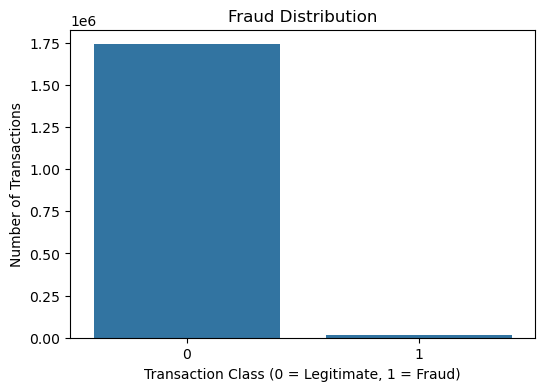

In [11]:
# Visualizing fraud and legitimate transaction distribution
plt.figure(figsize=(6,4))
sns.countplot(x='TX_FRAUD', data=final_df)
plt.title("Fraud Distribution")
plt.xlabel("Transaction Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

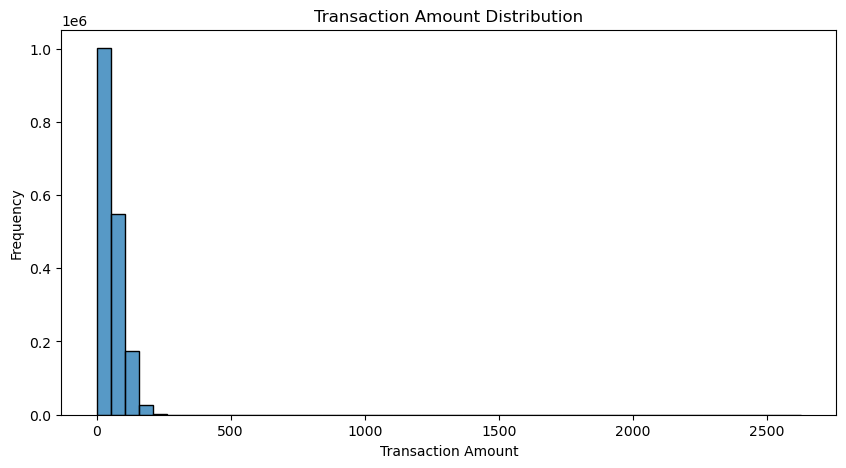

In [12]:
# Analyzing transaction amount distribution
plt.figure(figsize=(10,5))
sns.histplot(final_df['TX_AMOUNT'], bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

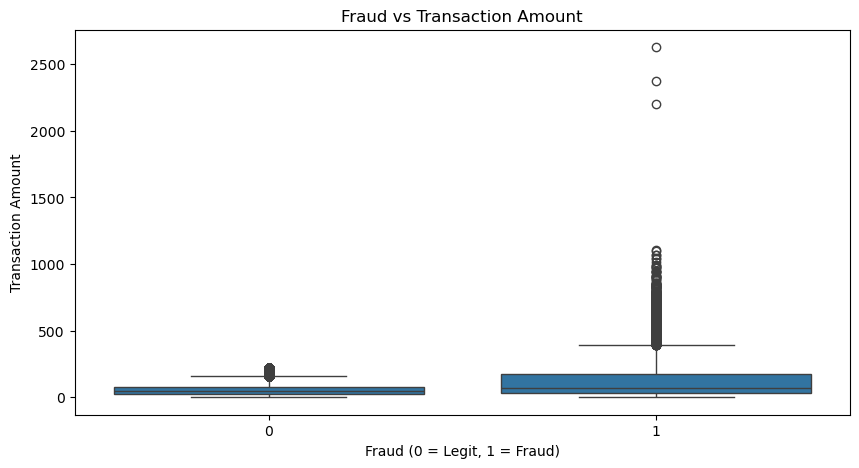

In [13]:
# Comparing transaction amounts for fraud and legitimate transactions
plt.figure(figsize=(10,5))
sns.boxplot(x='TX_FRAUD', y='TX_AMOUNT', data=final_df)
plt.title("Fraud vs Transaction Amount")
plt.xlabel("Fraud (0 = Legit, 1 = Fraud)")
plt.ylabel("Transaction Amount")
plt.show()

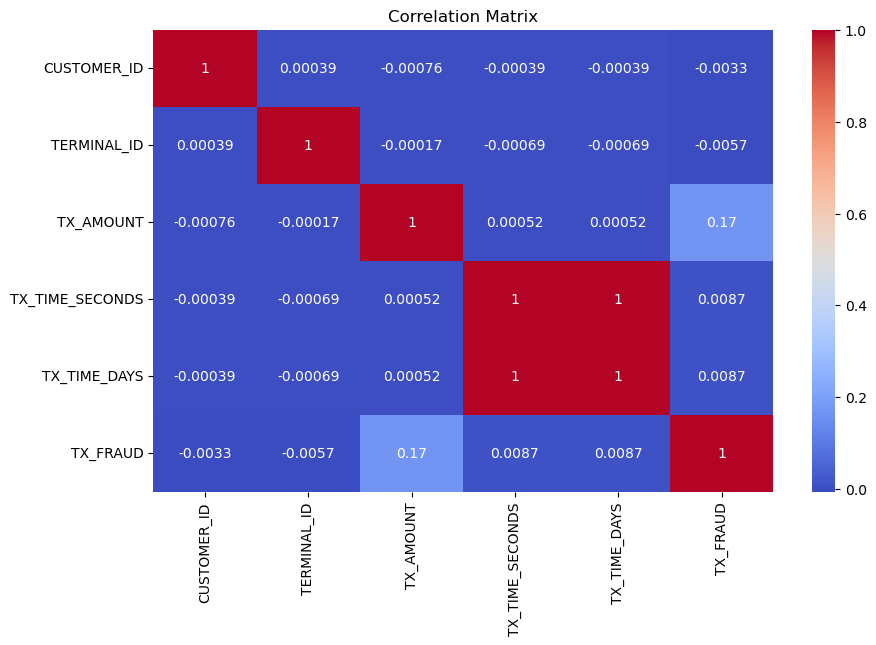

In [14]:
#Analyzing relationships between numerical features
plt.figure(figsize=(10,6))
correlation_matrix = final_df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## 6. Feature and Target Separation

In [15]:
# Features
X = final_df.drop('TX_FRAUD', axis=1)
# Target
y = final_df['TX_FRAUD']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1754155, 5)
y shape: (1754155,)


## 7. Train-Test Split

In [16]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1403324, 5)
X_test : (350831, 5)
y_train: (1403324,)
y_test : (350831,)


## 8. Model Training and Evaluation

In [17]:
# Initializing Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)

# Training the model
rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [18]:
# Prediction on test data
y_pred = rf_model.predict(X_test)

print("Predictions completed.")

Predictions completed.


In [19]:
# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9936465135635106
Precision: 1.0
Recall: 0.24080381471389645
F1 Score: 0.38814164150425473


In [20]:
#Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00    347895
           1       1.00      0.24      0.39      2936

    accuracy                           0.99    350831
   macro avg       1.00      0.62      0.69    350831
weighted avg       0.99      0.99      0.99    350831



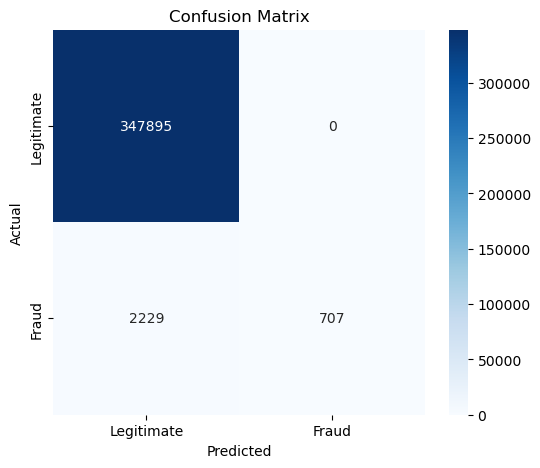

In [21]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualizing confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Legitimate', 'Fraud'],yticklabels=['Legitimate', 'Fraud'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 9. Feature Importance

In [22]:
# Extract feature importance scores from trained model
importance = rf_model.feature_importances_
# Create dataframe
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': importance})
# Sort features 
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

           Feature  Importance
2        TX_AMOUNT    0.371592
1      TERMINAL_ID    0.237032
3  TX_TIME_SECONDS    0.188240
0      CUSTOMER_ID    0.139084
4     TX_TIME_DAYS    0.064052


## 10. Handling Class Imbalance

### 10.1 Random Forest with Class Weights

In [23]:
# Training Random Forest using balanced class weights
rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
# Train model
rf_balanced.fit(X_train, y_train)
print("Balanced Random Forest trained successfully.")

Balanced Random Forest trained successfully.


In [24]:
# Predictions using balanced Random Forest model
y_pred_balanced = rf_balanced.predict(X_test)
print("Balanced model predictions completed.")

Balanced model predictions completed.


In [25]:
#Classification Report
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00    347895
           1       1.00      0.23      0.37      2936

    accuracy                           0.99    350831
   macro avg       1.00      0.61      0.69    350831
weighted avg       0.99      0.99      0.99    350831



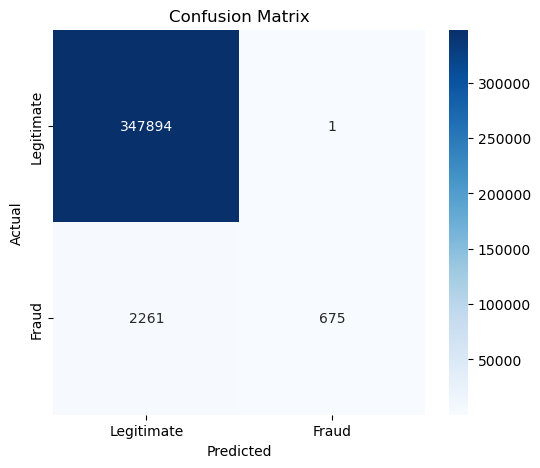

In [26]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred_balanced)

# Visualizing confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Legitimate', 'Fraud'],yticklabels=['Legitimate', 'Fraud'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 10.2 SMOTE Oversampling

In [27]:
# Creating a smaller subset to reduce computational cost during SMOTE experimentation
X_train_sample = X_train.sample(n=100000,random_state=42)
# Match corresponding target values
y_train_sample = y_train.loc[X_train_sample.index]

print(X_train_sample.shape)
print(y_train_sample.shape)

(100000, 5)
(100000,)


In [28]:
from imblearn.over_sampling import SMOTE
# Creating SMOTE object
smote = SMOTE(random_state=42)
# Apply SMOTE
X_smote, y_smote = smote.fit_resample(X_train_sample,y_train_sample)
# Checking new class distribution
print(y_smote.value_counts())

TX_FRAUD
0    99140
1    99140
Name: count, dtype: int64


In [29]:
# Training Random Forest model using SMOTE-balanced data
rf_smote = RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf_smote.fit(X_smote, y_smote)
print("Random Forest trained on SMOTE data successfully.")

Random Forest trained on SMOTE data successfully.


In [30]:
# Predictions using SMOTE-trained model
y_pred_smote = rf_smote.predict(X_test)
print("SMOTE model predictions completed.")

SMOTE model predictions completed.


In [31]:
#Classification Report
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.99      0.94      0.97    347895
           1       0.04      0.31      0.08      2936

    accuracy                           0.94    350831
   macro avg       0.52      0.63      0.52    350831
weighted avg       0.99      0.94      0.96    350831



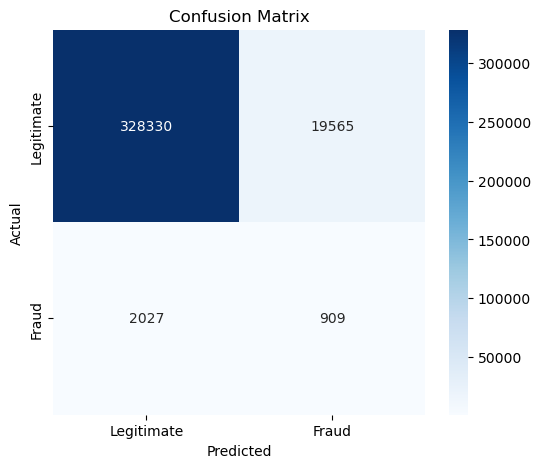

In [32]:
#Confusion matrix
cm = confusion_matrix(y_test, y_pred_smote)

# Visualizing confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Legitimate', 'Fraud'],yticklabels=['Legitimate', 'Fraud'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 11. Model Comparison

In [33]:
comparison = pd.DataFrame({'Model': ['Random Forest','Random Forest with Class Weights','SMOTE Random Forest'],
    'Accuracy': [0.99, 0.99, 0.94],
    'Precision': [1.00, 1.00, 0.04],
    'Recall': [0.24, 0.23, 0.31],
    'F1 Score': [0.39, 0.37, 0.08]})
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.99,1.00,0.24,0.39
1,Random Forest with Class Weights,0.99,1.00,0.23,0.37
2,SMOTE Random Forest,0.94,0.04,0.31,0.08


## 12. Final Model Selection

In this project, I developed a machine learning model to classify transactions as fraudulent or legitimate using transaction data.
The Random Forest model achieved an accuracy of 99.36% with perfect precision in fraud prediction. I also explored techniques such as Balanced Random Forest and SMOTE to address class imbalance. 
Although SMOTE improved recall, it significantly reduced precision, while the balanced class weight approach did not improve overall performance. Therefore, the  **Random Forest model** was selected as the final model due to its overall performance and reliability.

## 13. Prediction

In [34]:
# Testing model prediction using a sample transaction
sample_transaction = pd.DataFrame({'CUSTOMER_ID': [2513],'TERMINAL_ID': [1143],'TX_AMOUNT': [222.04],'TX_TIME_SECONDS': [104615],'TX_TIME_DAYS': [1]})
prediction = rf_model.predict(sample_transaction)
if prediction[0] == 1:
    print("Predicted Class: Fraud Transaction")
else:
    print("Predicted Class: Legitimate Transaction")

Predicted Class: Fraud Transaction


In [35]:
sample_transaction = pd.DataFrame({'CUSTOMER_ID': [596],'TERMINAL_ID': [3156],'TX_AMOUNT': [57.16],'TX_TIME_SECONDS': [31],'TX_TIME_DAYS': [0]})
prediction = rf_model.predict(sample_transaction)
if prediction[0] == 1:
    print("Predicted Class: Fraud Transaction")
else:
    print("Predicted Class: Legitimate Transaction")

Predicted Class: Legitimate Transaction


In [36]:
import joblib

#save model
joblib.dump(rf_model, "fraud_detection_model.pkl")

['fraud_detection_model.pkl']